In [1]:
import torch
import torchvision.utils as vutils
import matplotlib.pyplot as plt
import itertools
import os
import torch.nn as nn
import torch.nn.functional as F

batch_size = 128
image_size = 64
z_dim = 100
cond_dim = 3
ngf = 128
ndf = 128
nc = 3
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [2]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(z_dim, ngf * 8 * 4 * 4),
            nn.BatchNorm1d(ngf * 8 * 4 * 4),
            nn.ReLU(True)
        )
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(ngf * 8 + cond_dim, ngf * 4, 4, 2, 1),
            nn.BatchNorm2d(ngf * 4),
            nn.ReLU(True),
            nn.ConvTranspose2d(ngf * 4, ngf * 2, 4, 2, 1),
            nn.BatchNorm2d(ngf * 2),
            nn.ReLU(True),
            nn.ConvTranspose2d(ngf * 2, ngf, 4, 2, 1),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),
            nn.ConvTranspose2d(ngf, nc, 4, 2, 1),
            nn.Tanh()
        )

    def forward(self, z, labels):
        batch = z.size(0)
        x = self.fc(z).view(batch, ngf * 8, 4, 4)
        cond_map = labels.view(batch, cond_dim, 1, 1).expand(-1, -1, 4, 4)
        x = torch.cat([x, cond_map], dim=1)
        return self.deconv(x)

In [3]:
# Cell 7: Load Generator
checkpoint_path = r"model.pth"
G = Generator().to(device)
ckpt=torch.load(checkpoint_path, map_location=device)
G.load_state_dict(ckpt)
G.eval()

Generator(
  (fc): Sequential(
    (0): Linear(in_features=100, out_features=16384, bias=True)
    (1): BatchNorm1d(16384, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (deconv): Sequential(
    (0): ConvTranspose2d(1027, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(128, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (10): Tanh()
  )
)

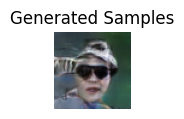

In [10]:
z = torch.randn(1, 100, device=device)

labels = torch.tensor([
    [0., 1., 1.]
]*1, device=device)


with torch.no_grad():
    generated = G(z, labels).cpu()

grid = vutils.make_grid(generated, nrow=1, normalize=True, value_range=(-1, 1), pad_value=1.0)

plt.figure(figsize=(1, 1))
plt.imshow(grid.permute(1, 2, 0))
plt.axis("off")
plt.title("Generated Samples")
plt.show()

In [11]:
num_combinations = 8
num_repeats = 8
nz = 100

z_base = torch.randn(num_repeats, nz, device=device)

z = z_base.repeat_interleave(num_combinations, dim=0)

#Male, Eyeglasses, No Beard
combinations = torch.tensor([
    [1., 0., 0.],
    [1., 1., 0.],
    [1., 0., 1.],
    [1., 1., 1.],
    [0., 0., 0.],
    [0., 0., 1.],
    [0., 1., 0.],
    [0., 1., 1.]
], device=device)

labels = combinations.repeat(num_repeats, 1)  # (64, 3)


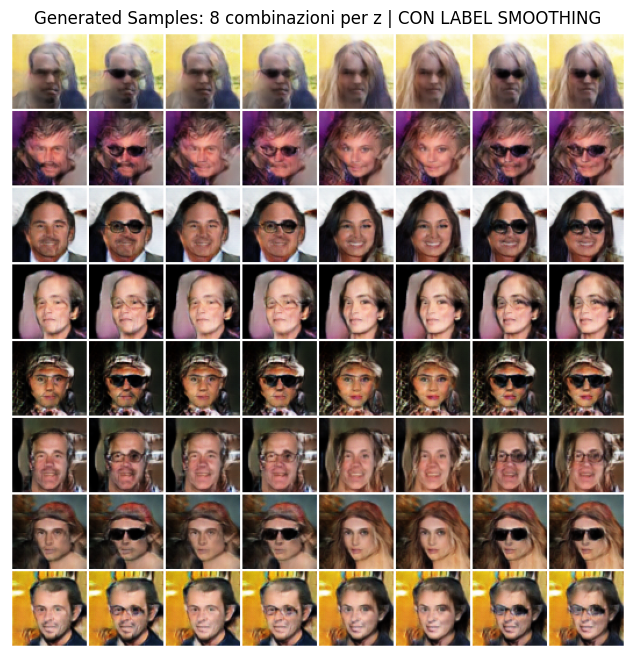

In [12]:
with torch.no_grad():
    generated = G(z, labels).cpu()

import torchvision.utils as vutils
import matplotlib.pyplot as plt

grid = vutils.make_grid(generated, nrow=8, normalize=True, value_range=(-1, 1), pad_value=1.0)

plt.figure(figsize=(12, num_repeats))
plt.imshow(grid.permute(1, 2, 0))
plt.axis("off")
plt.title("Generated Samples: 8 combinazioni per z | CON LABEL SMOOTHING")
plt.show()


In [13]:
def decode_label(label_tensor):
    g, e, b = [int(v) for v in label_tensor]
    gender = 'F' if g == 0 else 'M'
    glasses = 'Y' if e == 1 else 'N'
    beard = 'N' if b == 1 else 'Y'
    return f"{gender}_{glasses}_{beard}"

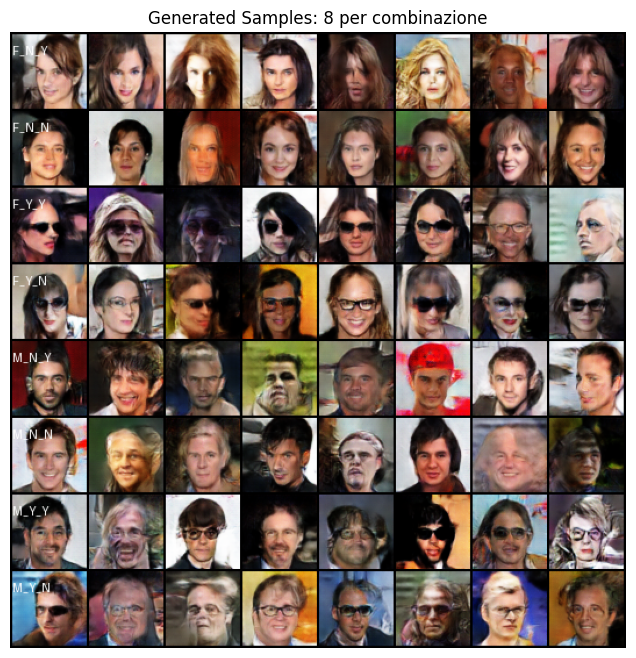

In [15]:
#epoca 20
import torch
import torchvision.utils as vutils
import matplotlib.pyplot as plt
from torchvision.transforms.functional import to_pil_image
from PIL import Image, ImageDraw, ImageFont

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Etichette combinate (Gender, Eyeglasses, Beard)
combinations = torch.tensor([
    [0., 0., 0.],
    [0., 0., 1.],
    [0., 1., 0.],
    [0., 1., 1.],
    [1., 0., 0.],
    [1., 0., 1.],
    [1., 1., 0.],
    [1., 1., 1.]
], device=device)

# Funzione per decodificare in stringa
def decode_label(label_tensor):
    g, e, b = [int(v.item()) for v in label_tensor]
    gender = 'F' if g == 0 else 'M'
    glasses = 'Y' if e == 1 else 'N'
    beard = 'N' if b == 1 else 'Y'
    return f"{gender}_{glasses}_{beard}"

# Parametri
z_dim = 100
num_per_comb = 8

# Generazione
all_images = []
labels_str = []

with torch.no_grad():
    for label in combinations:
        z = torch.randn(num_per_comb, z_dim, device=device)
        label_batch = label.unsqueeze(0).repeat(num_per_comb, 1)
        generated = G(z, label_batch).cpu()
        all_images.append(generated)
        labels_str.append(decode_label(label))

all_images = torch.cat(all_images, dim=0)
grid = vutils.make_grid(all_images, nrow=8, normalize=True)

grid_img = to_pil_image(grid)
draw = ImageDraw.Draw(grid_img)
try:
    font = ImageFont.truetype("DejaVuSans-Bold.ttf", 14)
except:
    font = ImageFont.load_default()

row_height = all_images.shape[2] + 2
for i, label_str in enumerate(labels_str):
    y = i * row_height + 10
    draw.text((2, y), label_str, fill=(255, 255, 255), font=font)

plt.figure(figsize=(8, 8))
plt.imshow(grid_img)
plt.axis("off")
plt.title("Generated Samples: 8 per combinazione")
plt.show()
